This project explores two predictive modeling problems using real-world datasets. The first investigates what drives residential housing prices in California, using demographic and geographic features to build and evaluate a Random Forest regression model. The second tackles a more complex challenge: forecasting national life expectancy using global development indicators, implemented through a neural network trained on World Bank data.
The central questions guiding this work are:

What socioeconomic and geographic factors best predict housing prices, and how accurately can a machine learning model capture them?
Can a neural network trained on development indicators from 2000–2019 reliably predict life expectancy outcomes in 2020?

Together, these analyses demonstrate an end-to-end machine learning workflow, from data wrangling and feature selection to model training, evaluation, and interpretation, applied to problems with real social and economic relevance.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
import time

In [13]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
np.random.seed(42)

In [14]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

In [15]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

Dataset Shape: (20640, 9)

First few rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Correlations with target:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


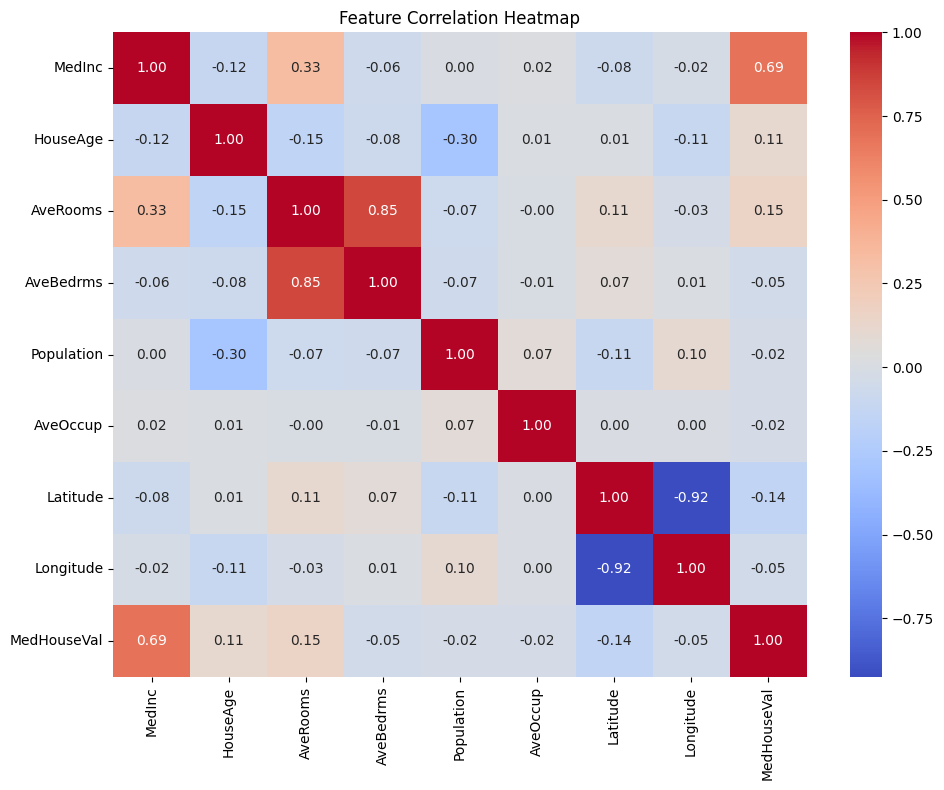

In [16]:
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nCorrelations with target:")
print(df.corr()['MedHouseVal'].sort_values(ascending=False))
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


MedInc (0.69) - STRONGEST predictor. Higher median income areas have much more expensive houses
AveRooms (0.15) - More rooms per household = slightly higher prices
HouseAge (0.11) - Slightly older homes are a bit more expensive (possibly historic/established neighborhoods)


Latitude (-0.14) - Houses further north tend to be cheaper (Southern CA more expensive)
AveBedrms (-0.05) - Surprisingly slight negative correlation

In [17]:
train_df, test_df = train_test_split(df, test_size=0.25, random_state=42)

In [18]:
train_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
8158,4.2143,37.0,5.288235,0.973529,860.0,2.529412,33.81,-118.12,2.285
18368,5.3468,42.0,6.364322,1.087940,957.0,2.404523,37.16,-121.98,2.799
19197,3.9191,36.0,6.110063,1.059748,711.0,2.235849,38.45,-122.69,1.830
3746,6.3703,32.0,6.000000,0.990196,1159.0,2.272549,34.16,-118.41,4.658
13073,2.3684,17.0,4.795858,1.035503,706.0,2.088757,38.57,-121.33,1.500


In [19]:
len(train_df), len(test_df)

(15480, 5160)

In [20]:
X_train = train_df.drop('MedHouseVal', axis=1)
y_train = train_df['MedHouseVal']
X_test = test_df.drop('MedHouseVal', axis=1)
y_test = test_df['MedHouseVal']

In [21]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
8158,4.2143,37.0,5.288235,0.973529,860.0,2.529412,33.81,-118.12
18368,5.3468,42.0,6.364322,1.087940,957.0,2.404523,37.16,-121.98
19197,3.9191,36.0,6.110063,1.059748,711.0,2.235849,38.45,-122.69
3746,6.3703,32.0,6.000000,0.990196,1159.0,2.272549,34.16,-118.41
13073,2.3684,17.0,4.795858,1.035503,706.0,2.088757,38.57,-121.33
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [22]:
y_train

,MedHouseVal
8158,2.285
18368,2.799
19197,1.830
3746,4.658
13073,1.500
...,...
11284,2.292
11964,0.978
5390,2.221
860,2.835


In [23]:
rf_cv = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf_cv, X_train, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
cv_rmse = np.sqrt(-cv_scores)

In [24]:
cv_rmse

array([0.500112  , 0.53199017, 0.48992866, 0.49962725, 0.53755941,
       0.51752616, 0.46364623, 0.52543821, 0.50672324, 0.51077375])

Random Forest creates many decision trees using different random samples of the data and then averages their outputs. By introducing randomness in both the data and the features used, it helps prevent overfitting.

Regression metrics:
RMSE: The square root of the average squared errors; keeps the units of the target and heavily penalizes big mistakes.
MAE: The average of absolute errors; less sensitive to outliers and easier to understand.
R²: Shows how much of the variation in the target the model explains; values closer to 1 indicate better performance.

In [26]:

fit_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
fit_rf.fit(X_train, y_train)

train_pred = fit_rf.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_rmse

np.float64(0.19115039372026807)

Random Forest is an ensemble of decision trees that averages predictions to reduce overfitting.

RMSE measures average prediction error in the same units as the target ($100k), making it interpretable.

In [27]:
test_predictions = fit_rf.predict(X_test)
X_test_copy = X_test.copy()
X_test_copy['predicted_price'] = test_predictions
X_test_copy['actual_price'] = y_test.values
X_test_copy

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,predicted_price,actual_price
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.502620,0.47700
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.713900,0.45800
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,4.900847,5.00001
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.649560,2.18600
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.352770,2.78000
...,...,...,...,...,...,...,...,...,...,...
5363,6.6260,51.0,5.532213,0.974790,771.0,2.159664,34.04,-118.42,4.574605,5.00001
19755,2.1898,30.0,4.509091,0.945455,410.0,2.484848,40.18,-122.21,0.816240,0.63200
4885,2.1667,37.0,3.272152,1.056962,2173.0,4.584388,34.02,-118.26,1.239130,1.17700
13043,6.8869,6.0,7.382385,1.030075,2354.0,2.528464,38.51,-121.06,3.034120,2.63100


Applying the trained model was much faster than training it because prediction only requires passing new data through the structures the model has already built. During training, the algorithm has to repeatedly process the dataset, build multiple decision trees, evaluate errors, and adjust how the model learns. This involves far more computation and time. In contrast, once the model is trained, making predictions is straightforward: the model simply uses the existing trees to generate an output with no additional learning or updates. As a result, applying the model is significantly quicker than training.

In [28]:
X_test_copy['percent_error'] = ((X_test_copy['actual_price'] - X_test_copy['predicted_price']) /
                                 X_test_copy['actual_price']) * 100
X_test_copy

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,predicted_price,actual_price,percent_error
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.502620,0.47700,-5.371069
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.713900,0.45800,-55.873362
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,4.900847,5.00001,1.983264
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.649560,2.18600,-21.205855
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.352770,2.78000,15.367986
...,...,...,...,...,...,...,...,...,...,...,...
5363,6.6260,51.0,5.532213,0.974790,771.0,2.159664,34.04,-118.42,4.574605,5.00001,8.508081
19755,2.1898,30.0,4.509091,0.945455,410.0,2.484848,40.18,-122.21,0.816240,0.63200,-29.151899
4885,2.1667,37.0,3.272152,1.056962,2173.0,4.584388,34.02,-118.26,1.239130,1.17700,-5.278675
13043,6.8869,6.0,7.382385,1.030075,2354.0,2.528464,38.51,-121.06,3.034120,2.63100,-15.321950


/tmp/ipython-input-3480460838.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for idx, (category, group) in enumerate(X_test_copy.groupby('income_category')):


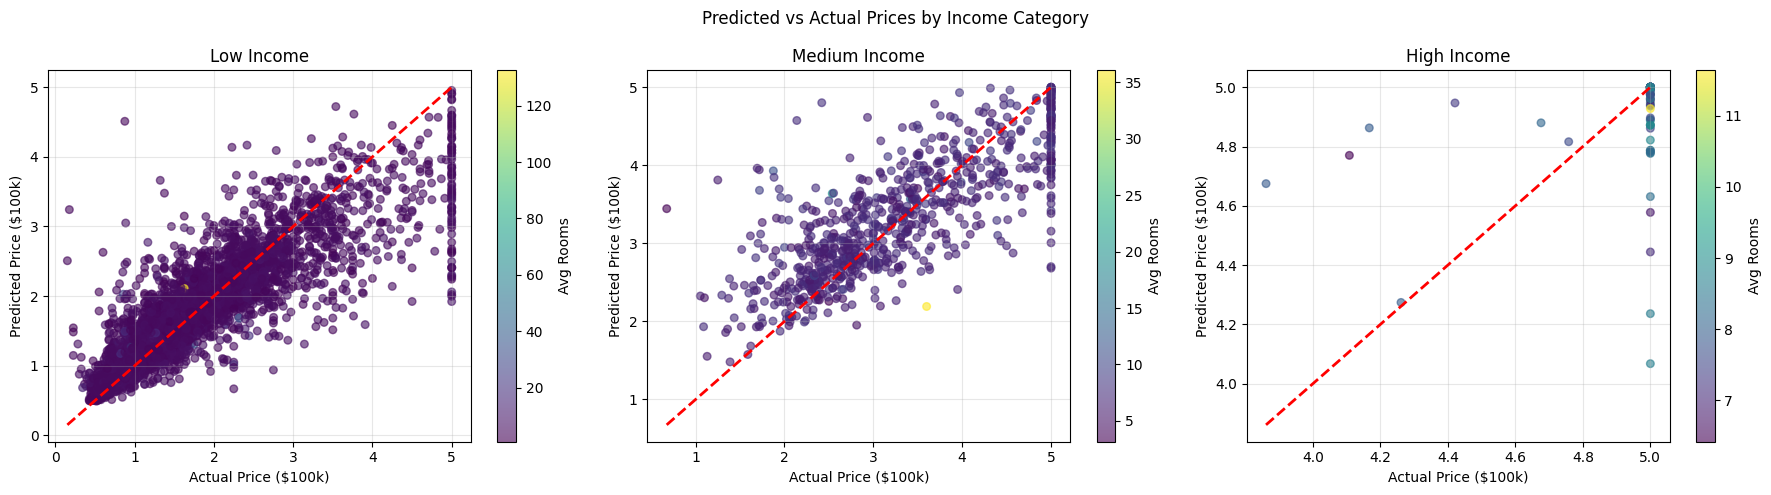

In [29]:
X_test_copy['income_category'] = pd.cut(X_test_copy['MedInc'], bins=3,
                                         labels=['Low', 'Medium', 'High'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (category, group) in enumerate(X_test_copy.groupby('income_category')):
    ax = axes[idx]
    scatter = ax.scatter(group['actual_price'], group['predicted_price'],
                        c=group['AveRooms'], cmap='viridis', alpha=0.6, s=30)

    min_val = min(group['actual_price'].min(), group['predicted_price'].min())
    max_val = max(group['actual_price'].max(), group['predicted_price'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

    ax.set_xlabel('Actual Price ($100k)')
    ax.set_ylabel('Predicted Price ($100k)')
    ax.set_title(f'{category} Income')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Avg Rooms')
plt.suptitle('Predicted vs Actual Prices by Income Category')
plt.tight_layout()
plt.savefig('predictions_by_income.png', dpi=300, bbox_inches='tight')
plt.show()

The model performs well with most pints clustering near the 45-degree line. Points above the line underpredicttion and points below the line showcase overprediction. Scatter increases at higher prices meaning there is less certainty for expensive properties.

Model Comparison:

Random Forest:
  RMSE: 0.5042
  MAE: 0.3291
  R²: 0.8079

Linear Regression:
  RMSE: 0.7356
  MAE: 0.5297
  R²: 0.5911

Baseline (Mean):
  RMSE: 1.1503
  MAE: 0.9100
  R²: -0.0000


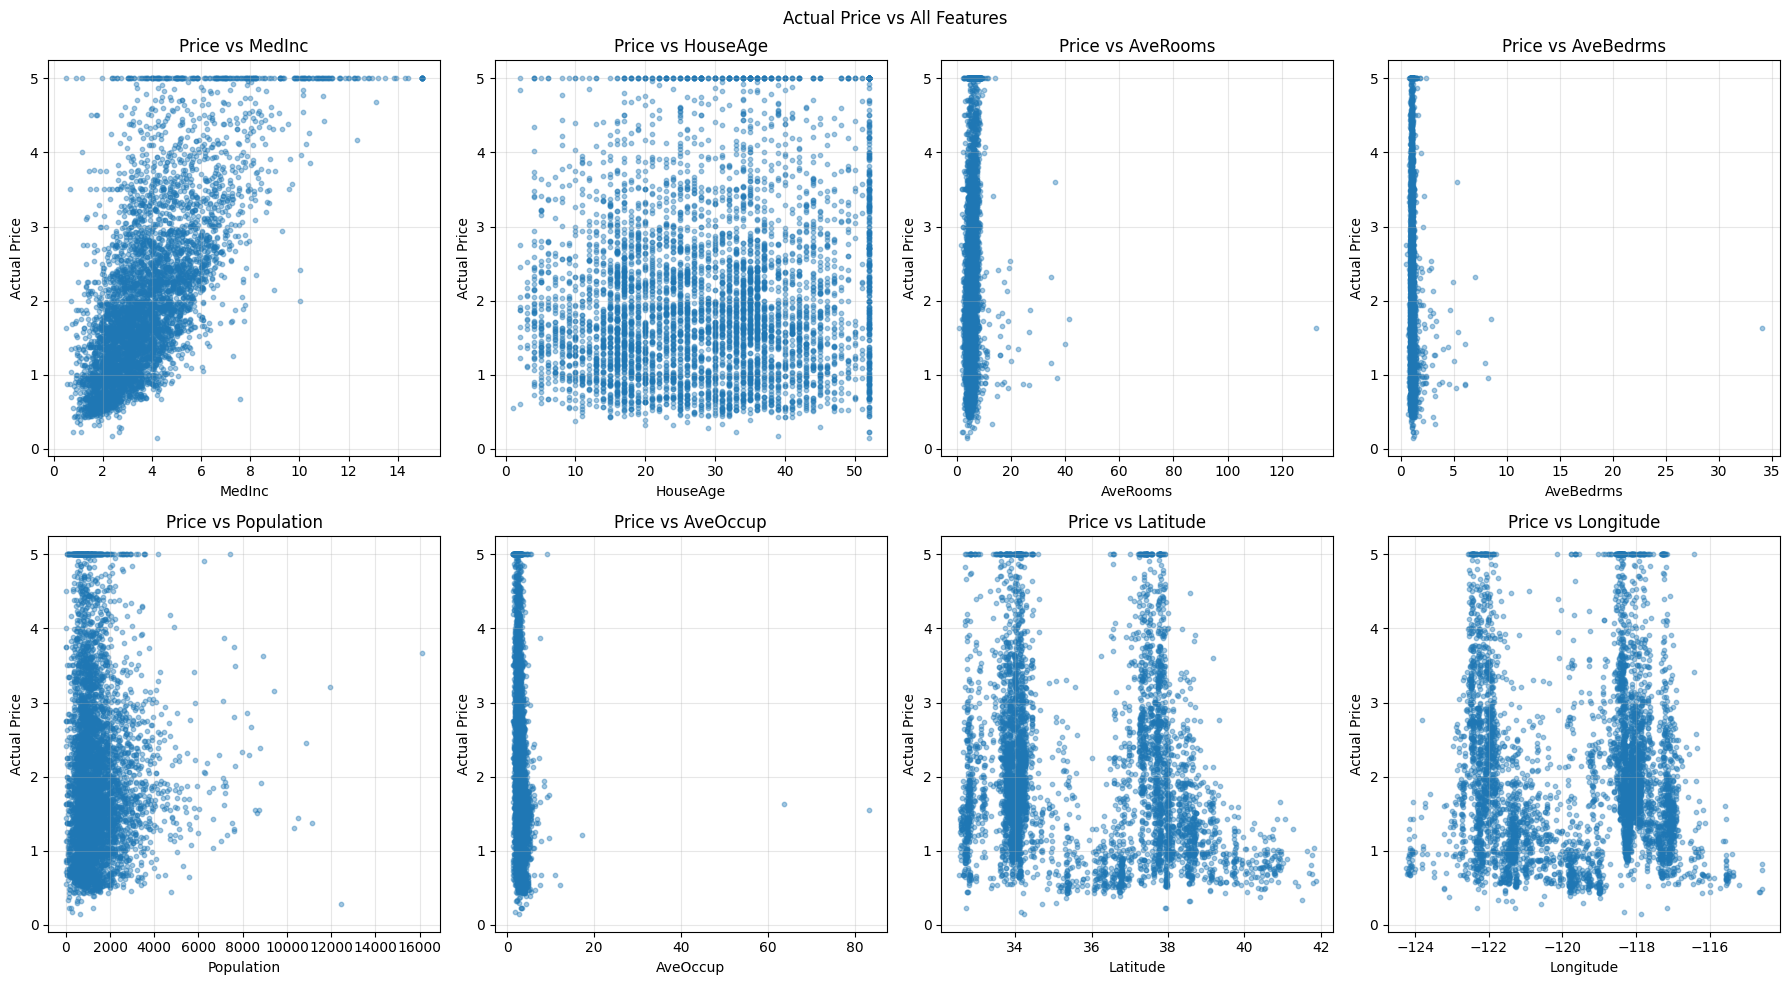


Feature Importance:
      Feature  Importance
0      MedInc    0.522230
5    AveOccup    0.139132
6    Latitude    0.088686
7   Longitude    0.088538
1    HouseAge    0.054108
2    AveRooms    0.045245
4  Population    0.031959
3   AveBedrms    0.030101


In [32]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
baseline_prediction = np.full(len(X_test), y_train.mean())

models = {
    'Random Forest': test_predictions,
    'Linear Regression': lr_predictions,
    'Baseline (Mean)': baseline_prediction
}

print("Model Comparison:")
for name, predictions in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"\n{name}:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R²: {r2:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
           'Population', 'AveOccup', 'Latitude', 'Longitude']

for idx, feature in enumerate(features):
    axes[idx].scatter(X_test_copy[feature], X_test_copy['actual_price'], alpha=0.4, s=10)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Actual Price')
    axes[idx].set_title(f'Price vs {feature}')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Actual Price vs All Features')
plt.tight_layout()
plt.savefig('price_vs_features.png', dpi=300, bbox_inches='tight')
plt.show()

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': fit_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

rf_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
improvement = ((lr_rmse - rf_rmse) / lr_rmse * 100)

In [ ]:
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)
test_r2

0.8078655075367563

The Random Forest outperformed because it captures non-linear relationships and feature interactions that linear regression cannot model. For example, the relationship between location (Latitude/Longitude) and price is complex and varies by region. Random Forest also handles the interaction between MedInc
and location better; high income matters more in certain areas than others.

The model can be useful as a supporting tool, but it should not be the only basis for decisions. It performs well for typical residential properties and can provide quick baseline valuations, help screen large numbers of listings, highlight potential under or overvalued homes, and show which factors drive prices in California. However, it is likely to struggle with properties that fall outside the patterns in the data, such as unique or luxury homes, recently renovated properties, houses with major structural issues, or homes in rapidly changing markets. It can also miss important factors like school quality, amenities, or unique lot characteristics. The best approach is to use the model for initial estimates and then combine its output with comparable sales, professional inspections, and local market expertise before making any final decisions.